In [1]:
# Install library yang diperlukan
!pip install roboflow inference-sdk ultralytics -q
!pip install "pillow>=10.0.0,<12.0.0" --force-reinstall -q

# Import libraries
import os
import yaml
from ultralytics import YOLO
from roboflow import Roboflow

print("✅ All dependencies installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 36.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 98.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

In [2]:
# Roboflow API
ROBOFLOW_API_KEY = "9MB6HuDZMWeL7udlSMWI"
WORKSPACE = "tes-j5ksp"
PROJECT = "tes-9dxsi"
VERSION = 1

# Training Parameters
EPOCHS = 50
IMG_SIZE = 640
BATCH_SIZE = 16
PATIENCE = 10
DEVICE = 0  # GPU: 0, CPU: 'cpu'
MODEL_NAME = "food-detection-v1"

# Disable W&B logging
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'

print("⚙️  Configuration set!")

⚙️  Configuration set!


In [3]:
# Inisialisasi Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Akses project dan download dataset
project = rf.workspace(WORKSPACE).project(PROJECT)
version = project.version(VERSION)
dataset = version.download("yolov8")

DATASET_PATH = dataset.location
print(f"✅ Dataset downloaded to: {DATASET_PATH}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to tes-1 in yolov8:: 100%|██████████| 41111/41111 [00:05<00:00, 7625.82it/s] 


✅ Dataset downloaded to: /kaggle/working/tes-1


In [4]:
# Baca data.yaml
data_yaml_path = os.path.join(DATASET_PATH, 'data.yaml')

with open(data_yaml_path, 'r') as f:
    data_info = yaml.safe_load(f)

print("📊 Dataset Info:")
print(f"   Path: {data_info.get('path', 'N/A')}")
print(f"   Classes: {data_info.get('nc', 'N/A')}")
print(f"   Names: {data_info.get('names', 'N/A')}")

# Lihat struktur folder
print("\n📁 Dataset Structure:")
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:
            print(f'{subindent}{file}')
        if len(files) > 5:
            print(f'{subindent}... and {len(files) - 5} more files')

📊 Dataset Info:
   Path: N/A
   Classes: 19
   Names: ['ayam goreng', 'bakso', 'bakwan', 'bubur ayam', 'ikan goreng', 'mangkuk', 'mie ayam', 'nasi', 'nasi goreng', 'nasi kuning', 'piring', 'rendang', 'sambal', 'sate', 'soto', 'tahu goreng', 'telur goreng', 'telur rebus', 'tempe goreng']

📁 Dataset Structure:
tes-1/
  README.roboflow.txt
  data.yaml
  README.dataset.txt
  test/
    images/
    labels/
  valid/
    images/
    labels/
  train/
    images/
    labels/


In [5]:
# ============================================================
# CELL 5: Fix Ray Tune (HAPUS TOTAL + BIKIN ULANG)
# ============================================================

import os

# Uninstall ray
!pip uninstall ray -y -q 2>/dev/null

# Cari path file raytune.py
ultralytics_path = !python -c "import ultralytics; print(ultralytics.__path__[0])"
ultralytics_path = ultralytics_path[0].strip()
raytune_path = os.path.join(ultralytics_path, 'utils', 'callbacks', 'raytune.py')

print(f"📍 Target file: {raytune_path}")

# HAPUS file lama
if os.path.exists(raytune_path):
    os.remove(raytune_path)
    print("🗑️  File lama dihapus!")

# BIKIN file baru dengan isi lengkap
with open(raytune_path, 'w') as f:
    f.write("""# Fixed raytune.py - compatible with all ray versions

callbacks = {}

def on_fit_epoch_end(trainer):
    pass

def on_train_end(trainer):
    pass

def on_train_start(trainer):
    pass

def on_val_end(trainer):
    pass
""")

# BACA ULANG isi file untuk verifikasi
print("\n📄 Isi file baru:")
with open(raytune_path, 'r') as f:
    print(f.read())

# RESTART KERNEL DULU SEBELUM IMPORT
import sys
import importlib

# Hapus cache module
if 'ultralytics.utils.callbacks.raytune' in sys.modules:
    del sys.modules['ultralytics.utils.callbacks.raytune']
if 'ultralytics.utils.callbacks' in sys.modules:
    del sys.modules['ultralytics.utils.callbacks']

# Import ulang
from ultralytics.utils.callbacks.raytune import callbacks
print(f"✅ VERIFIED: callbacks = {callbacks}")

📍 Target file: /usr/local/lib/python3.12/dist-packages/ultralytics/utils/callbacks/raytune.py
🗑️  File lama dihapus!

📄 Isi file baru:
# Fixed raytune.py - compatible with all ray versions

callbacks = {}

def on_fit_epoch_end(trainer):
    pass

def on_train_end(trainer):
    pass

def on_train_start(trainer):
    pass

def on_val_end(trainer):
    pass

✅ VERIFIED: callbacks = {}


In [6]:
# Load YOLOv8 nano pretrained
model = YOLO('yolov8n.pt')

# Path data.yaml
data_yaml = os.path.join(DATASET_PATH, 'data.yaml')

# Start training
results = model.train(
    data=data_yaml,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    name=MODEL_NAME,
    patience=PATIENCE,
    device=DEVICE
)

print("🎉 Training completed!")

Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/tes-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=food-detection-v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [7]:
# Validasi model
metrics = model.val()
print(f"\n📊 Validation Results:")
print(f"   mAP50: {metrics.box.map50:.4f}")
print(f"   mAP50-95: {metrics.box.map:.4f}")
print(f"   Precision: {metrics.box.mp:.4f}")
print(f"   Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,009,353 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2072.3±453.4 MB/s, size: 76.0 KB)
val: Scanning /kaggle/working/tes-1/valid/labels.cache... 2418 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2418/2418 1.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 152/152 7.4it/s 20.4s0.1s
                   all       2418       8019      0.861      0.832      0.889      0.721
           ayam goreng        358        693      0.817      0.747      0.823      0.587
                 bakso         99        148      0.875      0.939      0.936      0.815
                bakwan        114        638      0.846       0.73      0.867      0.643
            bubur ayam        156        174      0.943      0.948      0.979      0.842
           ikan goreng        257  

🔍 Testing on: nasi_543_jpg.rf.951133940aadc7b0dbf9cfc34967a91a.jpg

image 1/1 /kaggle/working/tes-1/test/images/nasi_543_jpg.rf.951133940aadc7b0dbf9cfc34967a91a.jpg: 640x640 1 piring, 1 rendang, 8.4ms
Speed: 2.0ms preprocess, 8.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


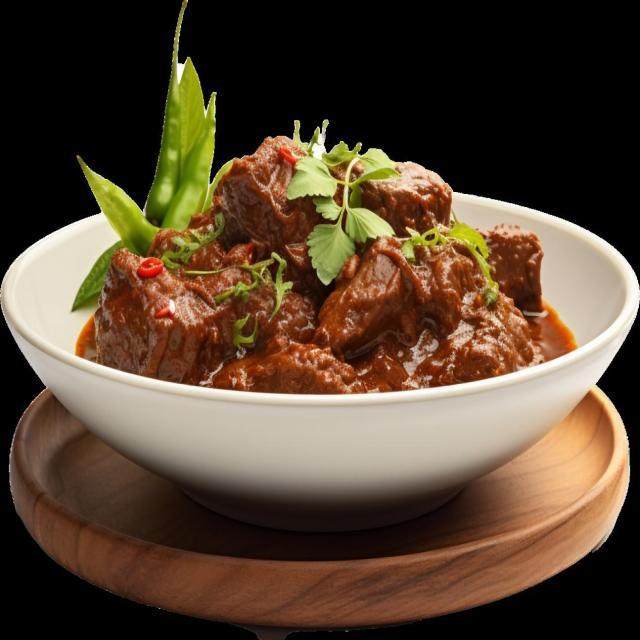

   📦 piring: 86.08%
   📦 rendang: 78.18%


In [8]:
import glob
from IPython.display import Image, display

# Cari gambar test random
test_images = glob.glob(os.path.join(DATASET_PATH, 'test', 'images', '*.jpg'))

if test_images:
    sample_img = test_images[0]
    print(f"🔍 Testing on: {os.path.basename(sample_img)}")
    
    # Run inference
    results = model.predict(sample_img, conf=0.5)
    
    # Display results
    display(Image(filename=sample_img))
    
    # Print detected objects
    for r in results:
        for box in r.boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            confidence = float(box.conf[0])
            print(f"   📦 {class_name}: {confidence:.2%}")
else:
    print("⚠️  No test images found!")




In [9]:
# ============================================================
# CELL 9: EXPORT MODEL - Download Ready
# ============================================================

import shutil
from google.colab import files

# Path model terlatih
model_path = os.path.join('runs', 'detect', MODEL_NAME, 'weights', 'best.pt')

# Export ke format yang diperlukan
print("📦 Exporting model...")

# 1. Export ke TensorFlow SavedModel (untuk TensorFlow Serving/FastAPI)
model.export(format='saved_model')
print("✅ Exported to TensorFlow SavedModel")

# 2. Export ke ONNX (optional, untuk deployment alternatif)
model.export(format='onnx')
print("✅ Exported to ONNX")

# List semua model yang tersedia
print("\n📁 Exported Models:")
export_dir = os.path.join('runs', 'detect', MODEL_NAME, 'weights')
for f in os.listdir(export_dir):
    size_mb = os.path.getsize(os.path.join(export_dir, f)) / (1024*1024)
    print(f"   📄 {f} ({size_mb:.1f} MB)")


📦 Exporting model...
Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/detect/food-detection-v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 23, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 277ms
Prepared 2 packages in 3.01s
Installed 2 packages in 9ms
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.5s, saved as '/kaggle/working/runs/detect/food-

E0000 00:00:1779774990.336401      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779774990.398629      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779774990.933687      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779774990.933711      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779774990.933713      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779774990.933716      57 computation_placer.cc:177] computation placer already registered. Please check linka

requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx2tf>=1.26.3,<1.29.0'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 1.18s
Prepared 5 packages in 263ms
Installed 5 packages in 7ms
 + ai-edge-litert==2.1.5
 + backports-strenum==1.3.1
 + onnx-graphsurgeon==0.6.1
 + onnx2tf==1.28.8
 + sng4onnx==2.0.1

requirements: AutoUpdate success ✅ 1.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


TensorFlow SavedModel: starting export with tensorflow 2.19.0...
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /kaggle/working/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 47.0files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...


I0000 00:00:1779775014.341370      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12905 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779775017.981120      57 cuda_dnn.cc:529] Loaded cuDNN version 91002


Saved artifact at '/kaggle/working/runs/detect/food-detection-v1/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 23, 8400), dtype=tf.float32, name=None)
Captures:
  136214660845200: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  136214660842704: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  136214660844432: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  136214660848656: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  136214660849808: TensorSpec(shape=(3, 3, 16, 32), dtype=tf.float32, name=None)
  136214660849424: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  136214660850000: TensorSpec(shape=(1, 1, 32, 32), dtype=tf.float32, name=None)
  136214660850192: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  136214660850960: TensorSpec(shape=(4,), dtype=tf.int6

I0000 00:00:1779775023.054730      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1779775023.054902      57 single_machine.cc:374] Starting new session
I0000 00:00:1779775023.062724      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12905 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
W0000 00:00:1779775023.780812      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779775023.780861      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1779775024.472087      57 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1779775024.472293      57 single_machine.cc:374] Starting new session
I0000 00:00:1779775024.480113      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12905 MB memory:  -> device: 0, name: Tesl

TensorFlow SavedModel: export success ✅ 43.1s, saved as '/kaggle/working/runs/detect/food-detection-v1/weights/best_saved_model' (29.3 MB)

Export complete (43.4s)
Results saved to /kaggle/working/runs/detect/food-detection-v1/weights/best_saved_model
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/food-detection-v1/weights/best_saved_model imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/food-detection-v1/weights/best_saved_model imgsz=640 data=/kaggle/working/tes-1/data.yaml  
Visualize:       https://netron.app
✅ Exported to TensorFlow SavedModel
Ultralytics 8.4.54 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/detect/food-detection-v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 23, 8400) (6.0 MB)

ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.0s, saved 

In [10]:
# ============================================================
# CELL 10: DOWNLOAD MODEL FILES
# ============================================================

# Opsi 1: Download best.pt (format Ultralytics, bisa langsung dipakai inference)
print("⬇️  Downloading best.pt...")
files.download(model_path)

# Opsi 2: Download SavedModel sebagai zip
savedmodel_path = os.path.join('runs', 'detect', MODEL_NAME, 'weights', f'{MODEL_NAME}_saved_model')
if os.path.exists(savedmodel_path):
    print("⬇️  Downloading SavedModel...")
    # Zip dulu
    shutil.make_archive(f'{MODEL_NAME}_saved_model', 'zip', savedmodel_path)
    files.download(f'{MODEL_NAME}_saved_model.zip')

# Opsi 3: Download semua model dalam satu zip
print("⬇️  Downloading all models...")
all_models_path = os.path.join('runs', 'detect', MODEL_NAME, 'weights')
shutil.make_archive(f'{MODEL_NAME}_all_models', 'zip', all_models_path)
files.download(f'{MODEL_NAME}_all_models.zip')

print("\n🎉 All done! Model files ready for deployment!")

⬇️  Downloading best.pt...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading all models...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All done! Model files ready for deployment!
